# 1. Importing

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(torch.__version__)

2.11.0+cu128


# 1.1 Data


In [ ]:
# Create some data using the linear regression formula of y = weight * X + bias
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]



(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

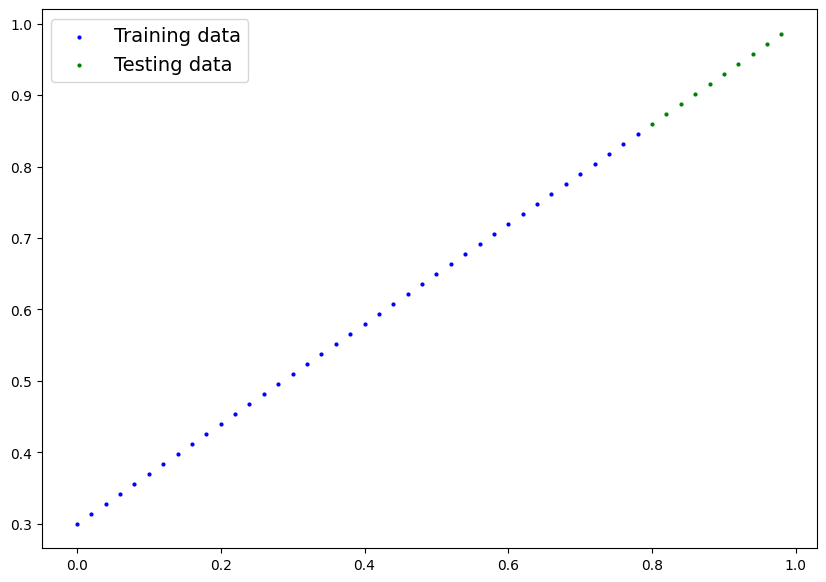

In [ ]:
# Plot the data
def plot_predictions(
    train_data=X_train,
    train_labels=y_train,
    test_data=X_test,
    test_labels=y_test,
    predictions=None,
):
    """Plots training data, test data and compares predictions."""
    plt.figure(figsize=(10, 7))

    # Eğitim verilerini mavi renkte çizdir
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Test verilerini yeşil renkte çizdir
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    # Eğer tahminler varsa kırmızı renkte çizdir
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Göstergeleri (Legend) ekle
    plt.legend(prop={"size": 14})


# Fonksiyonu çağır ve göster
plot_predictions()
plt.show()


# 1.2 Building a PyTorch Linear Model

In [ ]:
# Create a linear model by subsclassing nn.Module
class LinearRegressionModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        #Use nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(in_features=1, out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

# Set the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV1()
model_1, model_1.state_dict()

(LinearRegressionModelV1(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
# Check the model current device
next(model_1.parameters()).device

device(type='cpu')

In [ ]:
# Set the model to use the target device
device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)

model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

# 1.3 Training

For training we need:
* Loss function
* Optimizer
* Training loop
* Testing loop

In [ ]:
# Setup loss function and optimizer
loss_fn = nn.L1Loss() # same as MAE
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.01)

In [ ]:
# Let's write a training loop
torch.manual_seed(42)

epochs = 200

# Put data on the target device

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

# Create empty lists

test_loss_values = []
train_loss_values = []
epoch_count = []

# Training loop

for epoch in range(epochs):
    model_1.train()

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)

        test_loss = loss_fn(test_pred, y_test)

# Print out what's happening
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        train_loss_values.append(loss.detach().cpu().numpy())
        test_loss_values.append(test_loss.detach().cpu().numpy())

        print(
            f"Epoch: {epoch} | MAE Train Loss: {loss.item():.4f} | MAE Test Loss: {test_loss.item():.4f}"
        )




Epoch: 0 | MAE Train Loss: 0.5552 | MAE Test Loss: 0.5740
Epoch: 10 | MAE Train Loss: 0.4400 | MAE Test Loss: 0.4393
Epoch: 20 | MAE Train Loss: 0.3248 | MAE Test Loss: 0.3046
Epoch: 30 | MAE Train Loss: 0.2095 | MAE Test Loss: 0.1698
Epoch: 40 | MAE Train Loss: 0.0943 | MAE Test Loss: 0.0351
Epoch: 50 | MAE Train Loss: 0.0239 | MAE Test Loss: 0.0478
Epoch: 60 | MAE Train Loss: 0.0200 | MAE Test Loss: 0.0458
Epoch: 70 | MAE Train Loss: 0.0165 | MAE Test Loss: 0.0375
Epoch: 80 | MAE Train Loss: 0.0131 | MAE Test Loss: 0.0299
Epoch: 90 | MAE Train Loss: 0.0097 | MAE Test Loss: 0.0217
Epoch: 100 | MAE Train Loss: 0.0062 | MAE Test Loss: 0.0141
Epoch: 110 | MAE Train Loss: 0.0028 | MAE Test Loss: 0.0058
Epoch: 120 | MAE Train Loss: 0.0013 | MAE Test Loss: 0.0138
Epoch: 130 | MAE Train Loss: 0.0013 | MAE Test Loss: 0.0138
Epoch: 140 | MAE Train Loss: 0.0013 | MAE Test Loss: 0.0138
Epoch: 150 | MAE Train Loss: 0.0013 | MAE Test Loss: 0.0138
Epoch: 160 | MAE Train Loss: 0.0013 | MAE Test Loss

In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

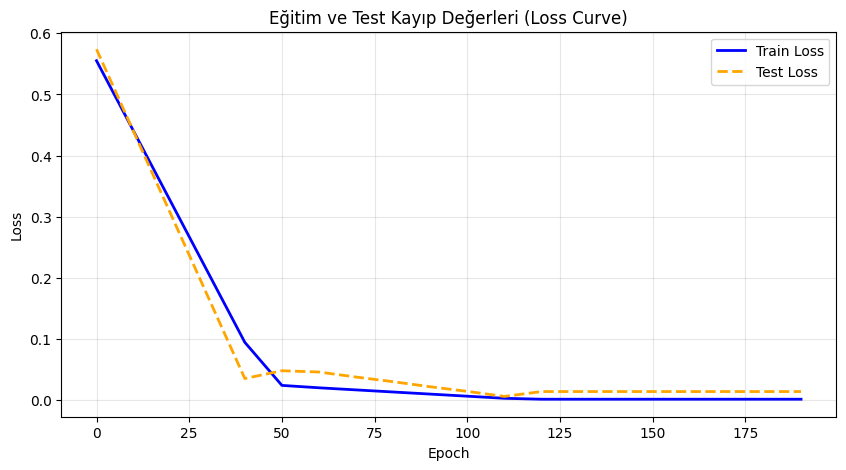

In [ ]:
# Listeler tensör içeriyorsa numpy dizisine dönüştür
train_loss = np.array(
    [
        l.detach().cpu().numpy() if isinstance(l, torch.Tensor) else l
        for l in train_loss_values
    ]
)
test_loss = np.array(
    [
        l.detach().cpu().numpy() if isinstance(l, torch.Tensor) else l
        for l in test_loss_values
    ]
)

plt.figure(figsize=(10, 5))
plt.plot(epoch_count, train_loss, label="Train Loss", color="blue", linewidth=2)
plt.plot(
    epoch_count,
    test_loss,
    label="Test Loss",
    color="orange",
    linestyle="--",
    linewidth=2,
)
plt.title("Eğitim ve Test Kayıp Değerleri (Loss Curve)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


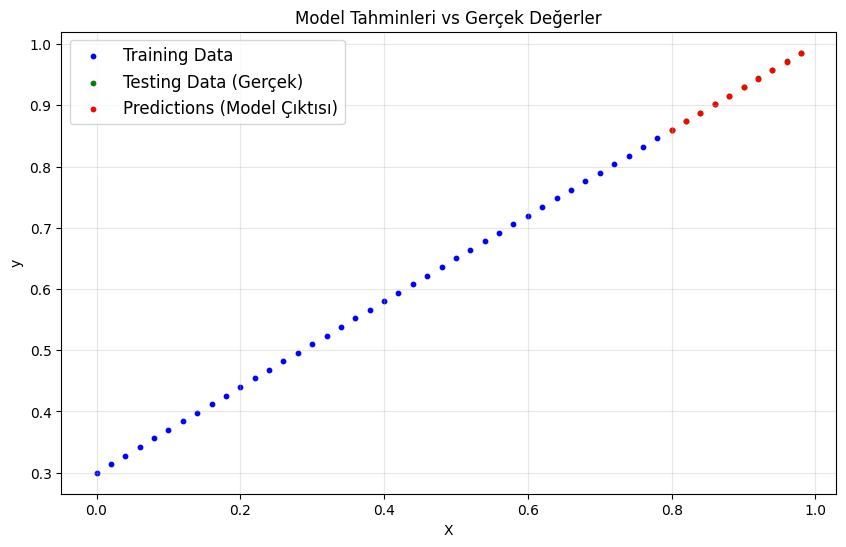

In [ ]:
# Modeli değerlendirme moduna alıp test verisi üzerinden tahmin üret
model_1.eval()
with torch.inference_mode():
    y_preds = model_1(X_test.to(device))


def plot_predictions(
    train_data=X_train,
    train_labels=y_train,
    test_data=X_test,
    test_labels=y_test,
    predictions=None,
):
    """Eğitim, test ve tahmin verilerini görselleştirir."""
    plt.figure(figsize=(10, 6))

    # Tensörleri CPU'ya taşıyıp numpy formatına dönüştürme fonksiyonu
    to_numpy = lambda t: t.detach().cpu().numpy() if isinstance(t, torch.Tensor) else t

    # Eğitim verileri (Mavi)
    plt.scatter(
        to_numpy(train_data),
        to_numpy(train_labels),
        c="b",
        s=10,
        label="Training Data",
    )

    # Test verileri (Yeşil)
    plt.scatter(
        to_numpy(test_data),
        to_numpy(test_labels),
        c="g",
        s=10,
        label="Testing Data (Gerçek)",
    )

    # Model tahminleri (Kırmızı)
    if predictions is not None:
        plt.scatter(
            to_numpy(test_data),
            to_numpy(predictions),
            c="r",
            s=10,
            label="Predictions (Model Çıktısı)",
        )

    plt.title("Model Tahminleri vs Gerçek Değerler")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend(prop={"size": 12})
    plt.grid(True, alpha=0.3)
    plt.show()


# Grafiği çizdir
plot_predictions(predictions=y_preds)

# Saving & loading a trained model

In [ ]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_1.pth


In [ ]:
# Load a PyTorch Model
loaded_model_1 = LinearRegressionModelV1()

# Load the saved model_1 state dict
loaded_model_1.load_state_dict(torch.load(f=MODEL_SAVE_PATH))


# Put the loaded model to device
loaded_model_1.to(device)

LinearRegressionModelV1(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
next(loaded_model_1.parameters()).device

device(type='cuda', index=0)

In [ ]:
loaded_model_1.state_dict()


OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [ ]:
# Evaluate loaded model
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)

y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')